# Master metrics figure: NBFF TT-GRU sweep

Applies the major CtD toolkit metrics to the same NBFF NODE-sweep models used in
`Figure1_NBFF_TTGRUSweep.ipynb` and renders them in a single composite figure.

Metrics:
1. **Reconstruction:** rate R², co-BPS
2. **Simplicity:** state R², cycle-consistency
3. **Input inference:** input R² *(not applicable for this benchmark — included as a placeholder panel)*
4. **Distributional:** Wasserstein (delay-embedded), KL (delay-embedded)
5. **DynSysID:** Lyapunov spectrum (max LE vs. latent size + spectrum heatmap)
6. **Qualitative:** fixed-point visualization for three representative models

In [1]:
import os

import dotenv
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA

from ctd.comparison.analysis.dd.dd import Analysis_DD
from ctd.comparison.analysis.tt.tt import Analysis_TT
from ctd.comparison.comparison import Comparison

dotenv.load_dotenv(dotenv.find_dotenv())
torch.manual_seed(42)
np.random.seed(42)

HOME_DIR = os.environ["HOME_DIR"]
print(HOME_DIR)

/home/csverst/Github/CtDBenchmark/


In [2]:
pathTT = HOME_DIR + "content/trained_models/task-trained/tt_3bff/"
an_TT = Analysis_TT(run_name="TT", filepath=pathTT)

path_NODE_Sweep = pathTT + "20250207_3BFF_NODE_sweep/"
subfolders_NODE = [f.path for f in os.scandir(path_NODE_Sweep) if f.is_dir()]

comparison = Comparison(comparison_tag="Master_NBFF_TTGRU_Sweep")
comparison.load_analysis(an_TT, reference_analysis=True, group="TT")

for subfolder in subfolders_NODE:
    subfolder = subfolder + "/"
    latent_size = subfolder.split("latent_size=")[1].split("_")[0]
    analysis_NODE = Analysis_DD.create(
        run_name=f"NODE{latent_size}",
        filepath=subfolder,
        model_type="SAE",
    )
    comparison.load_analysis(analysis_NODE, group=f"NODE{latent_size}")

comparison.regroup()

In [3]:
# Parse latent sizes from run names (skip the reference TT model with None)
latent_sizes_all = []
for an in comparison.analyses:
    if "NODE" in an.run_name:
        latent_sizes_all.append(int(an.run_name.split("NODE")[1]))
    else:
        latent_sizes_all.append(None)
print("Unique latent sizes:", sorted({l for l in latent_sizes_all if l is not None}))

Unique latent sizes: [3, 5, 8, 16, 32, 64]


In [4]:
# Compute the full set of scalar metrics through Comparison.compute_metrics.
# `wasserstein_geometry` / `kl_geometry` share the delay-embed pipeline; the
# defaults below match examples/compare_dd_tt_models_distribution_metrics.ipynb.
geometry_cfg = dict(
    input_source="latents",
    pca_dim=16,
    n_delays=2,
    delay_lag=1,
    temporal_bin_size=1,
    smoothing_window=1,
    covariance_reg=1e-5,
)

metric_dict_list = {
    "rate_r2": {},
    "co-bps": {},
    "state_r2": {},
    "cycle_con": {"variance_threshold": 0.01},
    "wasserstein_geometry": dict(geometry_cfg),
    "kl_geometry": dict(geometry_cfg),
}
metrics = comparison.compute_metrics(metric_dict_list=metric_dict_list)


Working on 1 of 31: NODE16
Rate R2: 0.9133415818214417
CO-BPS: 0.12676595151424408
State R2: 0.778888463973999
Cycle Consistency R2: 0.7742876410484314
Delay-Embed Wasserstein (latents): 0.6443762867494981
Delay-Embed Kl (latents): 1368.3743258011114

Working on 2 of 31: NODE16
Rate R2: 0.914481520652771
CO-BPS: 0.12701310217380524
State R2: 0.7769712805747986
Cycle Consistency R2: 0.7779019474983215
Delay-Embed Wasserstein (latents): 0.6152090998614793
Delay-Embed Kl (latents): 978.2765923890955

Working on 3 of 31: NODE16
Rate R2: 0.9063611030578613
CO-BPS: 0.125761479139328
State R2: 0.7998236417770386
Cycle Consistency R2: 0.8145898580551147
Delay-Embed Wasserstein (latents): 0.6412879048464928
Delay-Embed Kl (latents): 1542.6913869338284

Working on 4 of 31: NODE16
Rate R2: 0.9092665910720825
CO-BPS: 0.12613503634929657
State R2: 0.8460145592689514
Cycle Consistency R2: 0.8698435425758362
Delay-Embed Wasserstein (latents): 0.6580489060423288
Delay-Embed Kl (latents): 1307.7952960

In [5]:
# compute_metrics skips the reference TT model. Build a `latent_sizes` array
# whose rows align with the run_name list returned by compute_metrics.
metric_run_names = metrics["run_name"]
latent_sizes = np.array([
    int(name.split("NODE")[1]) if "NODE" in name else np.nan
    for name in metric_run_names
])

for k in ("rate_r2", "co-bps", "state_r2", "cycle_con",
         "wasserstein_geometry", "kl_geometry"):
    metrics[k] = np.asarray(metrics[k], dtype=float)

In [6]:
# Lyapunov spectrum per data-trained model. Each call returns (mean, std)
# vectors over the dynamics dimension; we keep the mean spectrum.
lyap_spectra = {}
for i, an in enumerate(comparison.analyses):
    if i == comparison.ref_ind or "NODE" not in an.run_name:
        continue
    try:
        lyap_mean, _ = an.compute_lyapunov_exp()
        spectrum = np.sort(np.asarray(lyap_mean.detach().cpu().numpy()))[::-1]
    except Exception as exc:
        print(f"Lyapunov failed for {an.run_name}: {exc}")
        continue
    lyap_spectra.setdefault(int(an.run_name.split("NODE")[1]), []).append(spectrum)

lyap_max_per_size = {
    k: np.array([s[0] for s in v]) for k, v in lyap_spectra.items()
}
lat_size_order = sorted(lyap_spectra.keys())
print("Lyapunov collected for latent sizes:", lat_size_order)

Lyapunov collected for latent sizes: [3, 5, 8, 16, 32, 64]


In [7]:
# Aggregate scalar metrics by latent size (mean across the 5 seeds per size).
def agg_by_size(values, sizes):
    unique = np.array(sorted({int(s) for s in sizes if np.isfinite(s)}))
    means = np.array([np.nanmean(values[sizes == s]) for s in unique])
    stds = np.array([np.nanstd(values[sizes == s]) for s in unique])
    return unique, means, stds

summary = {}
for k in ("rate_r2", "co-bps", "state_r2", "cycle_con",
         "wasserstein_geometry", "kl_geometry"):
    summary[k] = agg_by_size(metrics[k], latent_sizes)

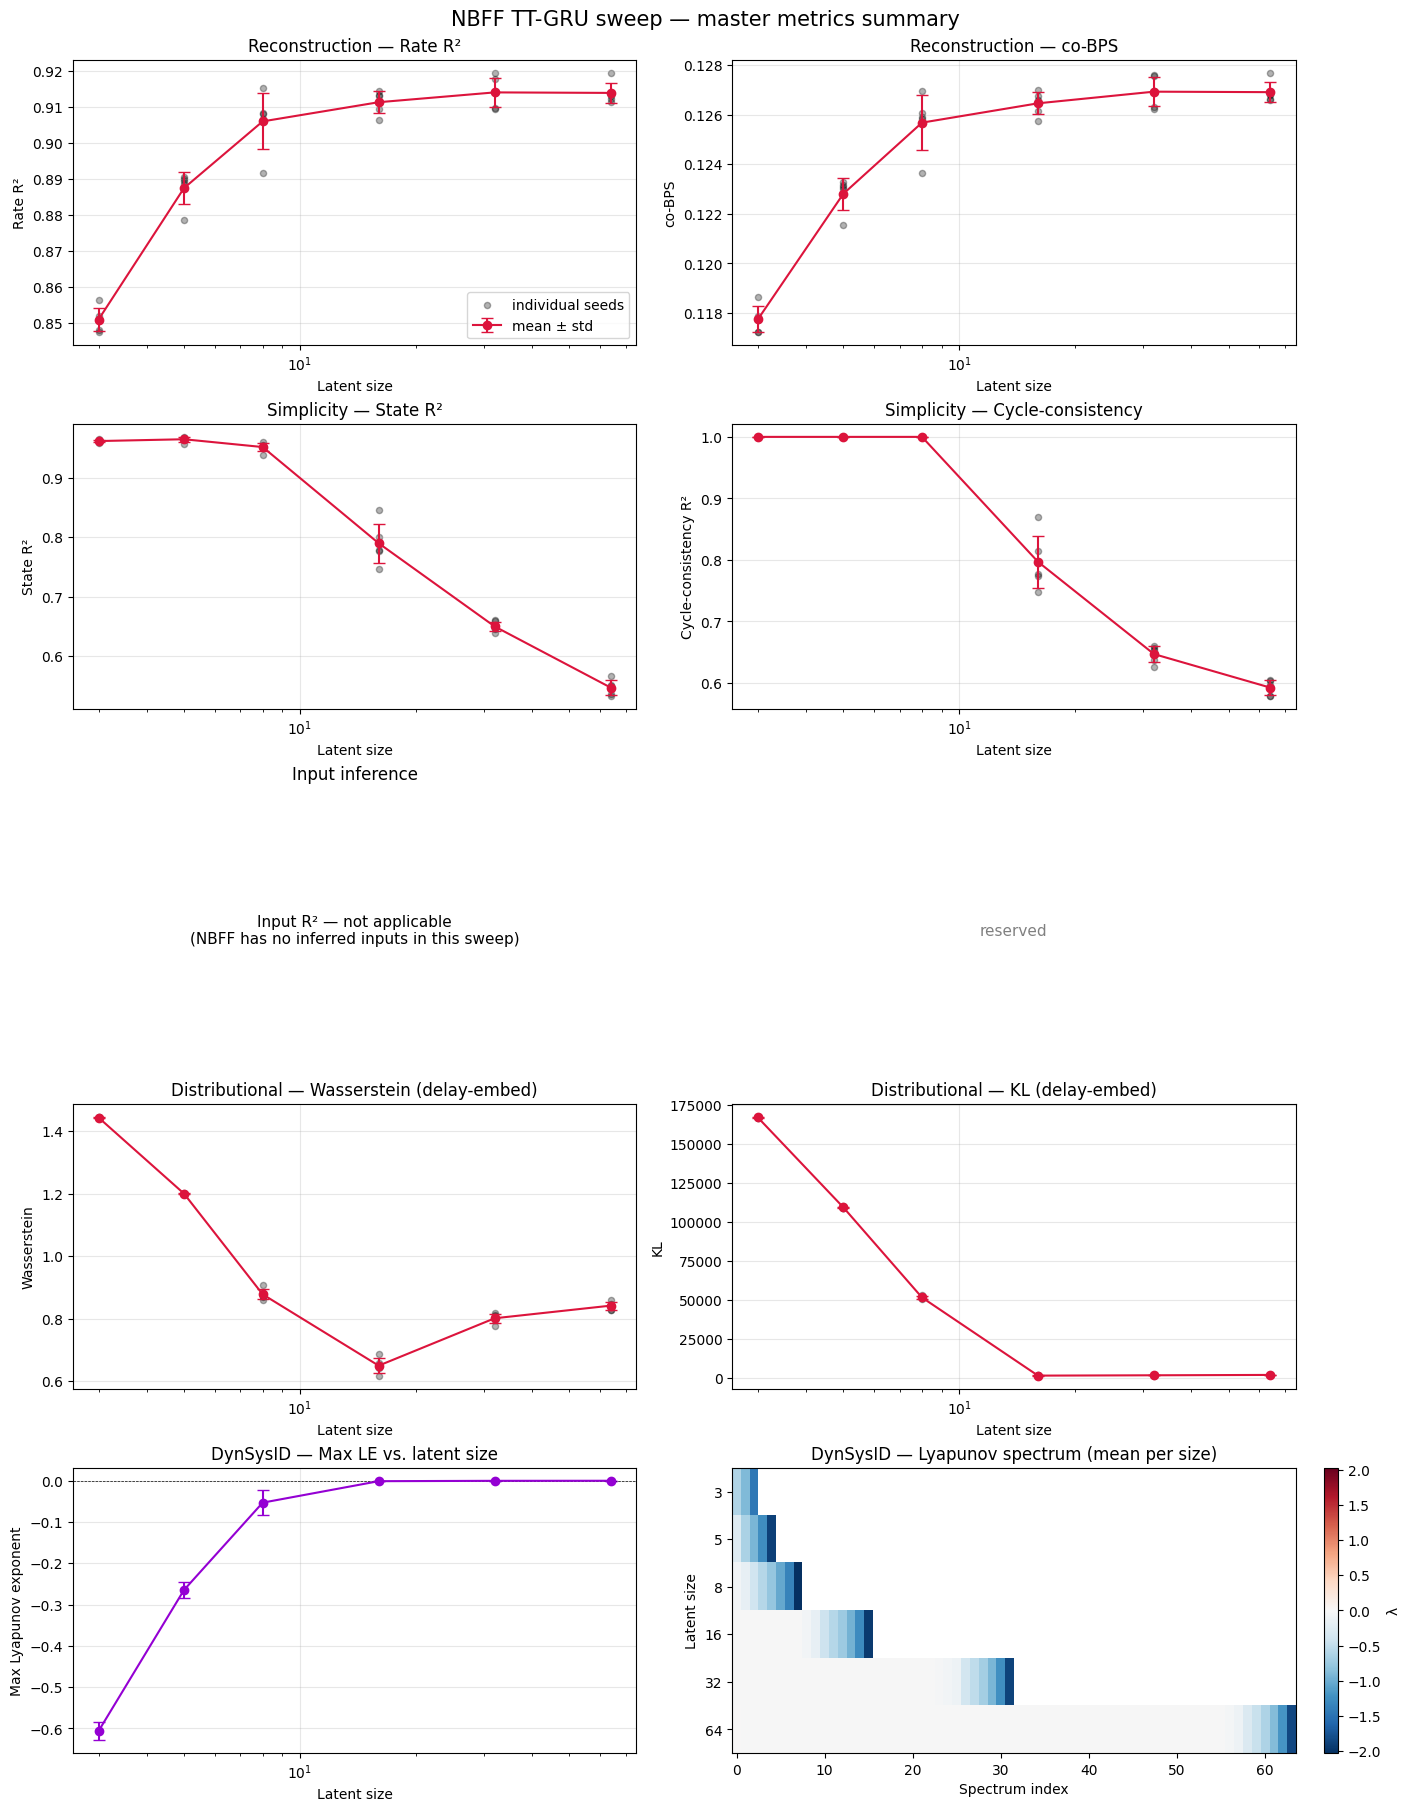

In [8]:
# Build the master figure.
fig = plt.figure(figsize=(14, 18), constrained_layout=True)
gs = fig.add_gridspec(5, 2)

def scatter_panel(ax, key, ylabel, log_y=False):
    sizes_u, means, stds = summary[key]
    ax.scatter(latent_sizes, metrics[key], c="k", alpha=0.3, s=20,
               label="individual seeds")
    ax.errorbar(sizes_u, means, yerr=stds, fmt="o-", color="crimson",
                capsize=4, label="mean ± std")
    ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel("Latent size")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

# Row 1: Reconstruction
ax = fig.add_subplot(gs[0, 0]); scatter_panel(ax, "rate_r2", "Rate R²")
ax.set_title("Reconstruction — Rate R²"); ax.legend(loc="lower right")
ax = fig.add_subplot(gs[0, 1]); scatter_panel(ax, "co-bps", "co-BPS")
ax.set_title("Reconstruction — co-BPS")

# Row 2: Simplicity
ax = fig.add_subplot(gs[1, 0]); scatter_panel(ax, "state_r2", "State R²")
ax.set_title("Simplicity — State R²")
ax = fig.add_subplot(gs[1, 1]); scatter_panel(ax, "cycle_con", "Cycle-consistency R²")
ax.set_title("Simplicity — Cycle-consistency")

# Row 3: Input inference (N/A for NBFF — placeholder panel + KL stand-in unused).
ax = fig.add_subplot(gs[2, 0])
ax.text(0.5, 0.5,
        "Input R² — not applicable\n(NBFF has no inferred inputs in this sweep)",
        ha="center", va="center", fontsize=11)
ax.set_axis_off(); ax.set_title("Input inference")
ax = fig.add_subplot(gs[2, 1])
ax.text(0.5, 0.5,
        "reserved", ha="center", va="center", fontsize=11, color="gray")
ax.set_axis_off()

# Row 4: Distributional metrics
ax = fig.add_subplot(gs[3, 0])
scatter_panel(ax, "wasserstein_geometry", "Wasserstein")
ax.set_title("Distributional — Wasserstein (delay-embed)")
ax = fig.add_subplot(gs[3, 1])
scatter_panel(ax, "kl_geometry", "KL")
ax.set_title("Distributional — KL (delay-embed)")

# Row 5: DynSysID — max Lyapunov vs latent size + spectrum heatmap
ax = fig.add_subplot(gs[4, 0])
max_means = [np.mean(lyap_max_per_size[s]) for s in lat_size_order]
max_stds = [np.std(lyap_max_per_size[s]) for s in lat_size_order]
ax.errorbar(lat_size_order, max_means, yerr=max_stds, fmt="o-",
            color="darkviolet", capsize=4)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xscale("log"); ax.set_xlabel("Latent size")
ax.set_ylabel("Max Lyapunov exponent")
ax.set_title("DynSysID — Max LE vs. latent size")
ax.grid(True, alpha=0.3)

ax = fig.add_subplot(gs[4, 1])
# Build a padded matrix of mean spectra (rows = latent sizes).
max_len = max(s.shape[0] for vals in lyap_spectra.values() for s in vals)
spec_mat = np.full((len(lat_size_order), max_len), np.nan)
for i, size in enumerate(lat_size_order):
    mean_spec = np.mean(np.stack([
        np.pad(s, (0, max_len - s.shape[0]), constant_values=np.nan)
        for s in lyap_spectra[size]
    ]), axis=0)
    spec_mat[i, :] = mean_spec
im = ax.imshow(spec_mat, aspect="auto", cmap="RdBu_r",
               vmin=-np.nanmax(np.abs(spec_mat)),
               vmax=np.nanmax(np.abs(spec_mat)))
ax.set_yticks(range(len(lat_size_order)))
ax.set_yticklabels(lat_size_order)
ax.set_xlabel("Spectrum index"); ax.set_ylabel("Latent size")
ax.set_title("DynSysID — Lyapunov spectrum (mean per size)")
fig.colorbar(im, ax=ax, label="λ")

fig.suptitle("NBFF TT-GRU sweep — master metrics summary", fontsize=15)
fig.savefig("Master_NBFF_AllMetrics.pdf", bbox_inches="tight")
plt.show()

## Qualitative: fixed-point visualization

Three representative latent sizes (under-, well-, over-parameterized) get their
own 3D FP plot. We pick the first seed per group.

{'NODE3': 5, 'NODE64': 20, 'NODE8': 25}

Iteration 500/5000
q = 1.88E-03 +/- 1.06E-02
dq = 2.48E-06 +/- 3.43E-05

Iteration 1000/5000
q = 1.48E-03 +/- 9.40E-03
dq = 3.80E-07 +/- 3.76E-06

Iteration 1500/5000
q = 1.24E-03 +/- 8.58E-03
dq = 8.98E-08 +/- 1.10E-06

Iteration 2000/5000
q = 1.24E-03 +/- 8.57E-03
dq = 1.76E-08 +/- 1.05E-07

Iteration 2500/5000
q = 1.23E-03 +/- 8.55E-03
dq = 1.87E-08 +/- 1.15E-07

Iteration 3000/5000
q = 1.23E-03 +/- 8.55E-03
dq = 4.05E-08 +/- 4.34E-07

Iteration 3500/5000
q = 1.23E-03 +/- 8.55E-03
dq = 2.62E-08 +/- 1.59E-07

Iteration 4000/5000
q = 1.23E-03 +/- 8.55E-03
dq = 3.26E-08 +/- 1.95E-07

Iteration 4500/5000
q = 1.23E-03 +/- 8.55E-03
dq = 2.19E-08 +/- 1.21E-07

Iteration 5000/5000
q = 1.23E-03 +/- 8.55E-03
dq = 4.12E-08 +/- 3.13E-07
Maximum iteration count reached. Terminating.
Found 512 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.

Iteration 500/5000
q = 3.86E-03 +/- 2.22E-02
dq = 2.71E-06 +/- 1.07E-

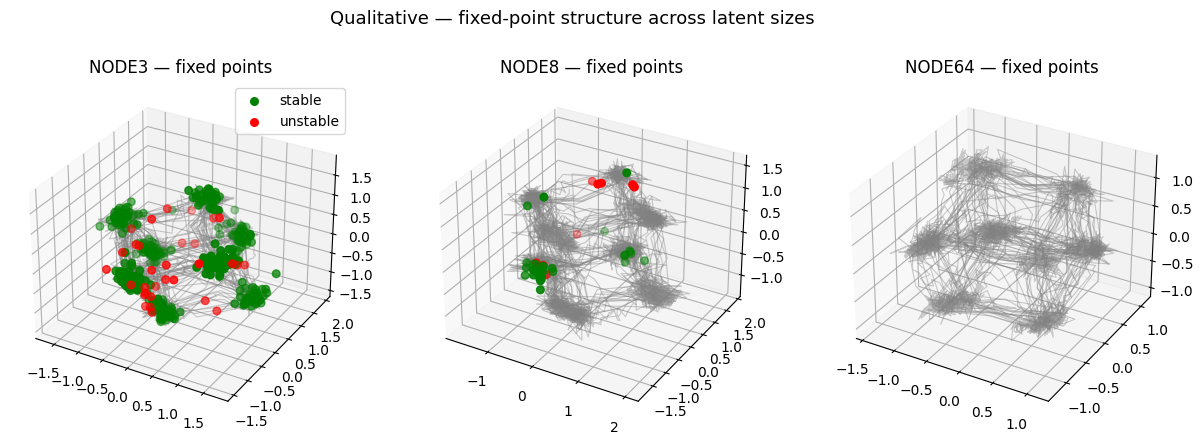

In [9]:
target_run_names = ["NODE3", "NODE8", "NODE64"]
first_occurrences = {}
for i, an in enumerate(comparison.analyses):
    if an.run_name in target_run_names and an.run_name not in first_occurrences:
        first_occurrences[an.run_name] = i
print(first_occurrences)

fp_fig = plt.figure(figsize=(15, 5))
for col, name in enumerate(target_run_names):
    idx = first_occurrences[name]
    an = comparison.analyses[idx]
    fps = an.compute_FPs(n_inits=512, max_iters=5000, device="cpu")
    xstar = fps.xstar
    qvals = fps.qstar
    is_stable = fps.is_stable
    q_flag = qvals < 1e-5

    latents = an.get_latents(phase="val").detach().cpu().numpy()
    pca = PCA(n_components=3)
    xstar_pca = pca.fit_transform(xstar)
    lats_pca = pca.transform(latents.reshape(-1, latents.shape[-1])).reshape(
        latents.shape[0], latents.shape[1], 3
    )

    ax = fp_fig.add_subplot(1, 3, col + 1, projection="3d")
    for t in range(min(15, lats_pca.shape[0])):
        ax.plot(lats_pca[t, :, 0], lats_pca[t, :, 1], lats_pca[t, :, 2],
                color="gray", alpha=0.4, lw=0.8)
    xs = xstar_pca[q_flag]; stab = is_stable[q_flag]
    ax.scatter(xs[stab, 0], xs[stab, 1], xs[stab, 2], c="g", s=30,
               label="stable")
    ax.scatter(xs[~stab, 0], xs[~stab, 1], xs[~stab, 2], c="r", s=30,
               label="unstable")
    ax.set_title(f"{name} — fixed points")
    if col == 0:
        ax.legend()

fp_fig.suptitle("Qualitative — fixed-point structure across latent sizes",
                fontsize=13)
fp_fig.savefig("Master_NBFF_AllMetrics_FPs.pdf", bbox_inches="tight")
plt.show()